# 01 — BPO SLA Performance: Data Understanding (EDA)

**Pregunta de negocio:** ¿cómo reducimos el % de incumplimiento de SLA y qué factores lo predicen, para optimizar la dotación de personal?

Este notebook cubre la fase **Data Understanding** del framework CRISP-DM adaptado: nulos, outliers, cardinalidad y detección de data leakage. No se hace feature engineering ni modelado todavía — eso corresponde a los notebooks siguientes (`02_data_preparation`, `03_modeling`).

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

DATA_PATH = '../data/call_metrics_dataset.csv'

## 2. Carga de datos

El CSV usa separador `;` y formato numérico europeo (coma decimal, punto de miles: `1.325,75` = 1325.75). Se especifica explícitamente al leer para evitar corromper `avg_aht` silenciosamente.

In [2]:
df = pd.read_csv(DATA_PATH, sep=';', decimal=',', thousands='.')
df['date'] = pd.to_datetime(df['date'])

print(df.shape)
df.head(10)

(270, 7)


,agent_id,date,product_id,lang_id,calls_handled,avg_aht,std_pass
0,10,2020-07-13,1,2,29,754.75,1
1,6,2020-07-15,2,2,18,432.03,1
2,10,2020-07-04,1,2,32,1325.75,0
3,4,2020-07-23,2,2,13,545.04,1
4,2,2020-07-20,3,2,6,86.19,0
5,9,2020-07-07,3,1,39,266.03,1
6,3,2020-01-17,1,1,12,1765.72,0
7,7,2020-07-07,1,1,28,1728.45,0
8,2,2020-07-16,2,2,6,598.08,0
9,4,2020-07-11,2,2,10,75.46,0


## 3. Estructura y tipos

El dataset real no coincide 1:1 con la descripción inicial del proyecto (que hablaba de tickets individuales con canal y hora). Lo que realmente tenemos es **una fila por combinación agente × fecha × producto × idioma**, con métricas ya agregadas a nivel diario:

| Columna | Significado |
|---|---|
| `agent_id` | id del agente (10 agentes) |
| `date` | fecha de la jornada |
| `product_id` | producto/cola atendida (3 valores) |
| `lang_id` | idioma del servicio (2 valores) |
| `calls_handled` | llamadas atendidas ese día por ese agente/producto/idioma |
| `avg_aht` | tiempo promedio de manejo (Average Handle Time), en segundos |
| `std_pass` | 1 si cumplió el estándar/SLA de AHT, 0 si no |

No hay columna de canal ni de hora — el análisis de "volumen por canal/hora" del alcance original se ajusta a "volumen por producto/idioma/día", que es lo que el dato permite responder.

In [3]:
df.dtypes

agent_id                  int64
date             datetime64[us]
product_id                int64
lang_id                   int64
calls_handled             int64
avg_aht                 float64
std_pass                  int64
dtype: object

## 4. Nulos

In [4]:
nulls = df.isnull().sum()
print(nulls)
assert nulls.sum() == 0, 'Hay nulos sin documentar'
print('\nSin valores nulos en ninguna columna.')

agent_id         0
date             0
product_id       0
lang_id          0
calls_handled    0
avg_aht          0
std_pass         0
dtype: int64

Sin valores nulos en ninguna columna.


## 5. Duplicados

In [5]:
print('Filas duplicadas exactas:', df.duplicated().sum())
print('Duplicados por clave agente+fecha+producto+idioma:',
      df.duplicated(subset=['agent_id', 'date', 'product_id', 'lang_id']).sum())

Filas duplicadas exactas: 0
Duplicados por clave agente+fecha+producto+idioma: 0


No hay duplicados. La clave `agent_id + date + product_id + lang_id` es única, consistente con que cada fila es una combinación agente/día/producto/idioma.

## 6. Cardinalidad de variables categóricas

In [6]:
for col in ['agent_id', 'product_id', 'lang_id']:
    print(f"{col}: {df[col].nunique()} valores únicos -> {sorted(df[col].unique())}")

agent_id: 10 valores únicos -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]
product_id: 3 valores únicos -> [np.int64(1), np.int64(2), np.int64(3)]
lang_id: 2 valores únicos -> [np.int64(1), np.int64(2)]


Baja cardinalidad en las tres — se tratan directamente como categóricas (10 agentes, 3 productos, 2 idiomas), sin necesidad de agrupar categorías raras.

## 7. Cobertura temporal — hallazgo de calidad de datos

Antes de analizar tendencias por fecha, hay que verificar que el dato esté completo y sea consistente en el tiempo.

In [7]:
print('Rango de fechas:', df['date'].min().date(), '->', df['date'].max().date())
print()
print('Filas por mes:')
print(df['date'].dt.to_period('M').value_counts().sort_index())
print()
print('Distribución de filas-por-fecha (cuántas fechas tienen 1 fila, cuántas tienen 9, etc.):')
print(df['date'].value_counts().value_counts().sort_index())

Rango de fechas: 2020-01-01 -> 2020-07-27

Filas por mes:
date
2020-01     27
2020-07    243
Freq: M, Name: count, dtype: int64

Distribución de filas-por-fecha (cuántas fechas tienen 1 fila, cuántas tienen 9, etc.):
count
1    27
9    27
Name: count, dtype: int64


**Hallazgo:** el dataset mezcla dos regímenes de granularidad distintos:

- **Enero 2020** (27 filas): una fila por día, sin desagregar por agente/producto/idioma dentro del día.
- **Julio 2020** (243 filas): 9 filas por día (subset de combinaciones agente×producto×idioma), es decir, sí desagregado.

Comparar directamente enero contra julio sería inconsistente porque no representan la misma unidad de análisis. **Decisión para la fase de Data Preparation:** o se excluye enero del análisis por agente, o se trata enero únicamente para tendencias agregadas a nivel diario (no por agente).

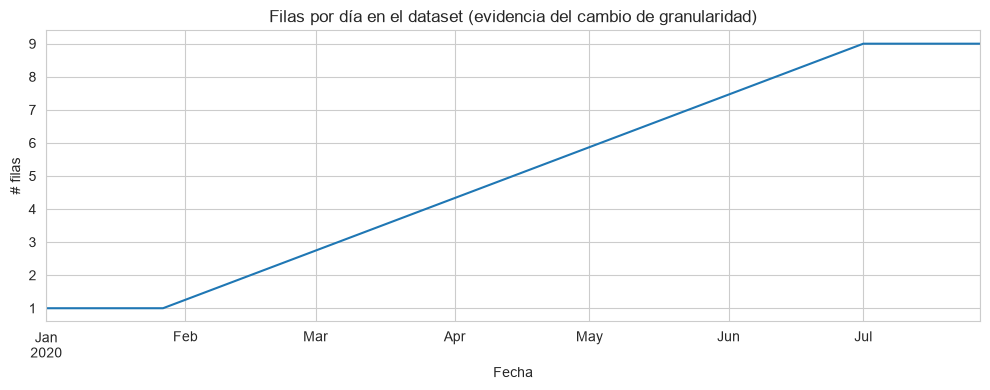

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
df.groupby(df['date'].dt.to_period('D')).size().plot(ax=ax)
ax.set_title('Filas por día en el dataset (evidencia del cambio de granularidad)')
ax.set_xlabel('Fecha')
ax.set_ylabel('# filas')
plt.tight_layout()
plt.show()

## 8. Outliers en variables numéricas

In [9]:
df[['calls_handled', 'avg_aht']].describe()

,calls_handled,avg_aht
count,270.000000,270.000000
mean,19.992593,691.167333
std,10.364363,568.868008
min,1.000000,8.080000
25%,11.000000,209.067500
50%,20.000000,510.955000
75%,29.000000,973.752500
max,39.000000,2992.150000


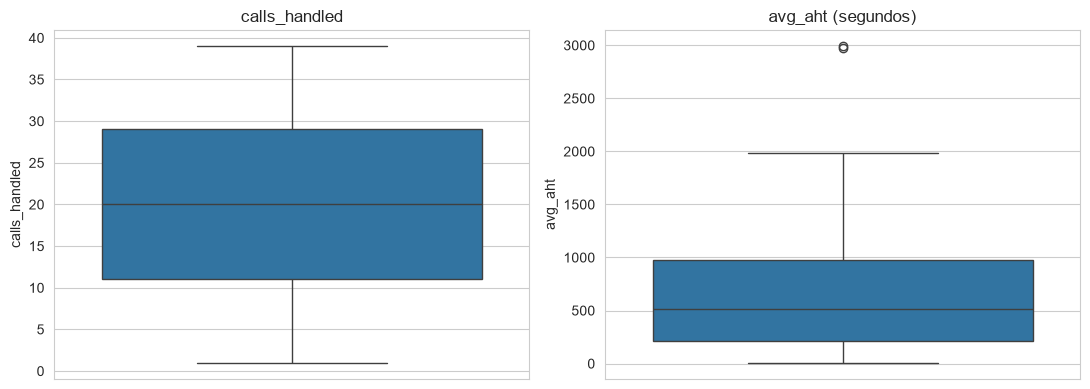

calls_handled: 0 outliers fuera de [-16.0, 56.0] (regla IQR 1.5x)
avg_aht: 2 outliers fuera de [-938.0, 2120.8] (regla IQR 1.5x)


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.boxplot(y=df['calls_handled'], ax=axes[0])
axes[0].set_title('calls_handled')
sns.boxplot(y=df['avg_aht'], ax=axes[1])
axes[1].set_title('avg_aht (segundos)')
plt.tight_layout()
plt.show()

def iqr_outliers(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return ((s < lo) | (s > hi)).sum(), lo, hi

for col in ['calls_handled', 'avg_aht']:
    n_out, lo, hi = iqr_outliers(df[col])
    print(f"{col}: {n_out} outliers fuera de [{lo:.1f}, {hi:.1f}] (regla IQR 1.5x)")

`avg_aht` tiene cola larga hacia la derecha (algunos agentes/días con tiempos de manejo muy por encima del resto), pero dentro de rangos plausibles para un call center (segundos, no horas) — no se observan valores imposibles (negativos, ceros, o magnitudes fuera de escala). `calls_handled` no muestra outliers relevantes.

## 9. Variable objetivo: `std_pass`

std_pass
0    0.392593
1    0.607407
Name: proportion, dtype: float64


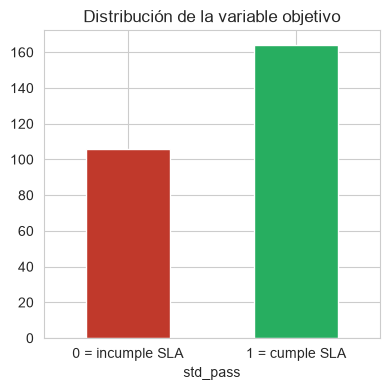

In [11]:
rate = df['std_pass'].value_counts(normalize=True).sort_index()
print(rate)

fig, ax = plt.subplots(figsize=(4, 4))
df['std_pass'].value_counts().sort_index().plot(kind='bar', ax=ax, color=['#c0392b', '#27ae60'])
ax.set_xticklabels(['0 = incumple SLA', '1 = cumple SLA'], rotation=0)
ax.set_title('Distribución de la variable objetivo')
plt.tight_layout()
plt.show()

~39% de las combinaciones agente/día/producto/idioma incumplen el estándar. Es un desbalance moderado (no extremo como en fraude), por lo que un modelo de clasificación puede entrenarse sin necesidad de técnicas agresivas de rebalanceo — aunque conviene revisarlo de nuevo tras separar train/test.

## 10. Detección de data leakage — hallazgo crítico

`avg_aht` es, por definición de negocio, la métrica que se compara contra el estándar para producir `std_pass`. Si `avg_aht` se usa como *feature* para predecir `std_pass`, el modelo no estaría prediciendo el incumplimiento — estaría re-descubriendo el propio umbral con el que se calculó la etiqueta. Se verifica esa hipótesis explícitamente.

          count         mean    min       50%      max
std_pass                                              
0         106.0  1076.666604   8.08  1283.700  2992.15
1         164.0   442.003171  18.43   398.885  1190.16


C:\Users\migue\AppData\Local\Temp\ipykernel_23184\1503666699.py:5: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['0 = incumple', '1 = cumple'])


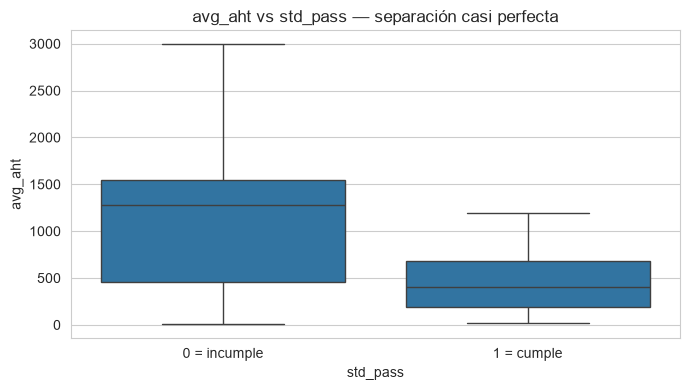

In [12]:
print(df.groupby('std_pass')['avg_aht'].describe()[['count', 'mean', 'min', '50%', 'max']])

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df, x='std_pass', y='avg_aht', ax=ax)
ax.set_xticklabels(['0 = incumple', '1 = cumple'])
ax.set_title('avg_aht vs std_pass — separación casi perfecta')
plt.tight_layout()
plt.show()

**Confirmado: hay leakage.** Las distribuciones de `avg_aht` para `std_pass=0` y `std_pass=1` casi no se superponen (medianas de ~1284s vs ~399s), lo que es consistente con que `std_pass` esté derivado directamente de `avg_aht` contra un umbral (posiblemente distinto por producto/agente, ya que la separación no es perfectamente limpia).

**Decisión para Data Preparation / Modeling:**
- `avg_aht` **no debe usarse como feature** para predecir `std_pass` — sería predecir la etiqueta con la propia etiqueta disfrazada.
- El modelo predictivo (científico) debe reformularse sobre variables verdaderamente *disponibles antes del resultado*: `agent_id`, `product_id`, `lang_id`, `calls_handled`, y features temporales derivadas de `date` (día de semana, tendencia). Esto se documentará en el README del proyecto.
- Alternativa a evaluar en el notebook de modelado: predecir `avg_aht` (regresión) en lugar de `std_pass` (clasificación), y aplicar el umbral de negocio *después* de la predicción — evita el leakage por construcción.

## 11. Análisis descriptivo (enfoque analista): incumplimiento por agente y producto

Con el leakage ya documentado, esta sección es puramente descriptiva/diagnóstica — no se usa para modelar, sino para entender dónde se concentra el incumplimiento. Se restringe a julio (granularidad agente/producto/idioma consistente, ver sección 7).

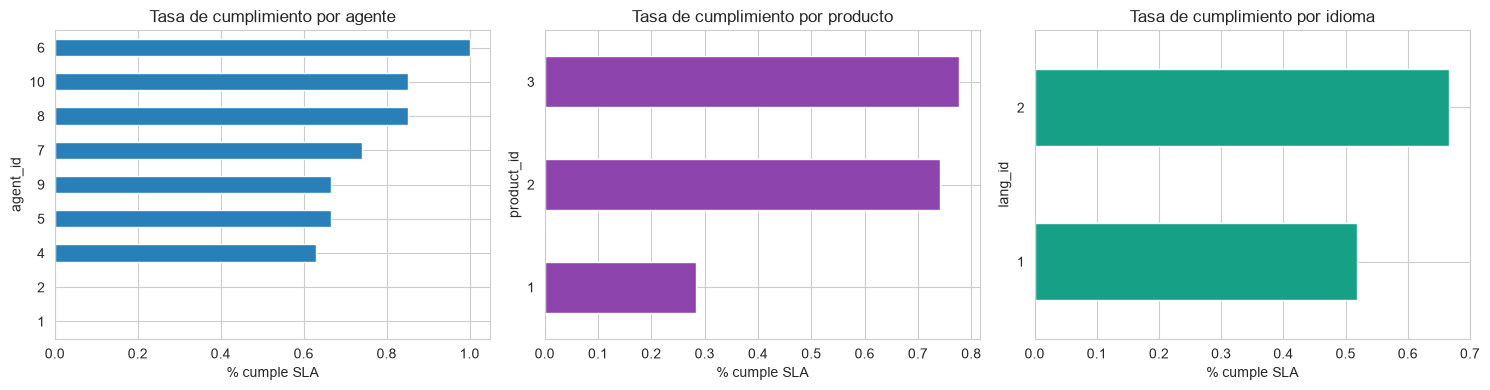

Tasa de cumplimiento por agente:
agent_id
1     0.000000
2     0.000000
4     0.629630
5     0.666667
9     0.666667
7     0.740741
8     0.851852
10    0.851852
6     1.000000
Name: std_pass, dtype: float64


In [13]:
df_jul = df[df['date'].dt.month == 7].copy()
df_jul['dow'] = df_jul['date'].dt.day_name()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

agent_rate = df_jul.groupby('agent_id')['std_pass'].mean().sort_values()
agent_rate.plot(kind='barh', ax=axes[0], color='#2980b9')
axes[0].set_title('Tasa de cumplimiento por agente')
axes[0].set_xlabel('% cumple SLA')

product_rate = df_jul.groupby('product_id')['std_pass'].mean().sort_values()
product_rate.plot(kind='barh', ax=axes[1], color='#8e44ad')
axes[1].set_title('Tasa de cumplimiento por producto')
axes[1].set_xlabel('% cumple SLA')

lang_rate = df_jul.groupby('lang_id')['std_pass'].mean().sort_values()
lang_rate.plot(kind='barh', ax=axes[2], color='#16a085')
axes[2].set_title('Tasa de cumplimiento por idioma')
axes[2].set_xlabel('% cumple SLA')

plt.tight_layout()
plt.show()

print('Tasa de cumplimiento por agente:')
print(agent_rate)

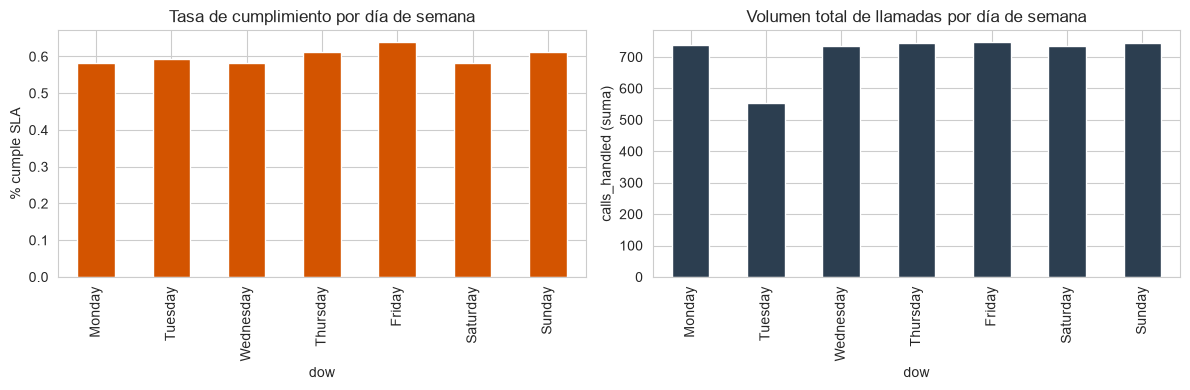

In [14]:
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
dow_rate = df_jul.groupby('dow')['std_pass'].mean().reindex(dow_order)
dow_volume = df_jul.groupby('dow')['calls_handled'].sum().reindex(dow_order)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dow_rate.plot(kind='bar', ax=axes[0], color='#d35400')
axes[0].set_title('Tasa de cumplimiento por día de semana')
axes[0].set_ylabel('% cumple SLA')

dow_volume.plot(kind='bar', ax=axes[1], color='#2c3e50')
axes[1].set_title('Volumen total de llamadas por día de semana')
axes[1].set_ylabel('calls_handled (suma)')

plt.tight_layout()
plt.show()

## 12. Volumen vs. desempeño

Chequeo rápido de la intuición de workforce planning: ¿a mayor volumen de llamadas atendidas, cae la tasa de cumplimiento (saturación de agentes)?

C:\Users\migue\AppData\Local\Temp\ipykernel_23184\2266959988.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(['0 = incumple', '1 = cumple'])


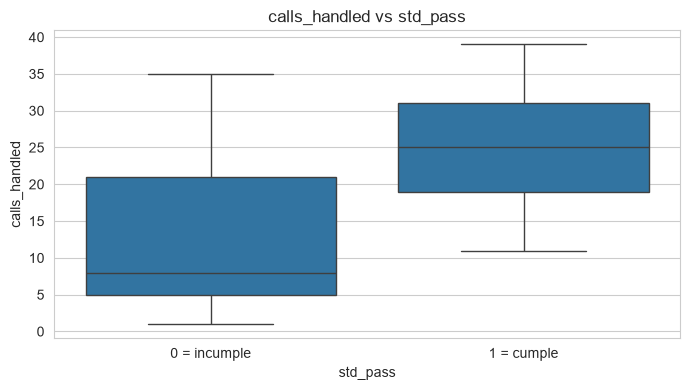

          count       mean   50%
std_pass                        
0          97.0  13.268041   8.0
1         146.0  25.410959  25.0


In [15]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=df_jul, x='std_pass', y='calls_handled', ax=ax)
ax.set_xticklabels(['0 = incumple', '1 = cumple'])
ax.set_title('calls_handled vs std_pass')
plt.tight_layout()
plt.show()

print(df_jul.groupby('std_pass')['calls_handled'].describe()[['count', 'mean', '50%']])

## 13. Conclusiones de la fase de Data Understanding

1. **Calidad de datos:** sin nulos ni duplicados. El separador `;` y el formato numérico europeo (`,` decimal / `.` miles) deben manejarse explícitamente al leer el CSV, o `avg_aht` se corrompe silenciosamente.
2. **Inconsistencia de granularidad:** enero 2020 (27 filas, 1/día) y julio 2020 (243 filas, 9/día) no son comparables directamente — se resuelve en Data Preparation, no ignorando el problema.
3. **Cardinalidad baja** en `agent_id` (10), `product_id` (3) y `lang_id` (2): tratables directamente como categóricas, sin necesidad de target encoding ni agrupación de categorías raras.
4. **Desbalance moderado** de la variable objetivo (~61% cumple / ~39% incumple): no requiere SMOTE ni técnicas agresivas, pero se revisará tras el split train/test.
5. **Data leakage confirmado:** `avg_aht` determina casi por completo `std_pass` y debe excluirse como feature del modelo predictivo. El modelo de clasificación de riesgo deberá apoyarse en `agent_id`, `product_id`, `lang_id`, `calls_handled` y variables temporales derivadas de `date` — o reformularse como regresión sobre `avg_aht` con el umbral de negocio aplicado después.

**Siguiente paso:** `02_data_preparation.ipynb` — resolver la inconsistencia de granularidad, construir features temporales, y dejar el dataset listo para el modelo de clasificación de riesgo de incumplimiento de SLA.